In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log
from sympy import symbols, diff, solve, N, evalf
from scipy import optimize

def f(x):
    y = 8-x
    return x ** y

def df(x):
    return x**(8 - x)*(-np.log(x) + (8 - x)/x)
    

def solve_with_brute_force(n=1_000_000):
    xs = np.linspace(0, 8, n)
    ys = f(xs)
    index = np.argmax(ys)
    return xs[index]

# SymPy setup
x, y = symbols('x y')
y = x ** (8-x)
dy = diff(y)

def plot_function_and_derivative():
    xs = np.linspace(1e-32, 8, 100)
    ys = f(xs)
    dys = df(xs)
    x_max = solve_with_brent_bounded()

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, label=r'$f(x) = x^{8-x}$')  # Label for the function
    plt.plot(xs, dys, label=r"$f'(x) = x^{8-x} \left(-\log(x) + \frac{8-x}{x}\right)$")  # Label for the derivative
    plt.axvline(x=x_max, label=f"Max: {x_max:.6f}", color='gray', linestyle='dashed', lw=1)
    plt.grid(True)
    plt.xlim(0, 8)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend(loc='upper right')
    plt.title("Function and Derivative")

def solve_with_sympy():
    return float(solve(dy)[0])

def solve_with_brent_bounded():
    result = optimize.minimize_scalar(lambda x: -f(x), bounds=(0, 8), method='bounded')
    return result.x

def solve_with_newton_raphson():
    newton_raphson_x, result = optimize.newton(df, x0=4, full_output=True)
    return newton_raphson_x

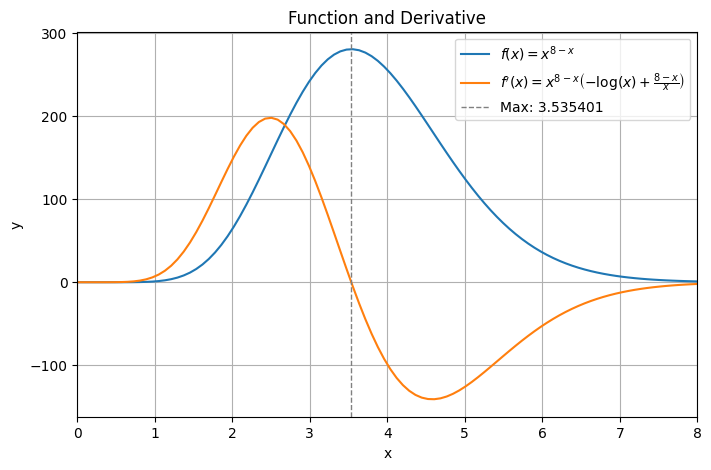

In [2]:
plot_function_and_derivative()

In [3]:
solutions_dict = {
    "Brute Force": solve_with_brute_force(),
    "Newton-Raphson": solve_with_newton_raphson(),
    "Brent-Bounded": solve_with_brent_bounded(),
    "SymPy": solve_with_sympy(),
}
for method, solution in solutions_dict.items():
    print(f'{method:>15}: {solution}')

    Brute Force: 3.535403535403535
 Newton-Raphson: 3.5354010355601555
  Brent-Bounded: 3.5354011909593237
          SymPy: 3.5354010355601524


In [4]:
%timeit solve_with_brute_force()
%timeit solve_with_newton_raphson()
%timeit solve_with_brent_bounded()
%timeit solve_with_sympy()

41.1 ms ± 703 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
201 µs ± 2.07 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
124 µs ± 1.02 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
344 ms ± 3.96 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
def brents_root_finding_method(f, a, b, tol=1e-10, max_iter=1000):
    fa = f(a)
    fb = f(b)
    assert fa * fb < 0, "The function must have different signs at a and b"

    if abs(fa) < abs(fb):
        a, b = b, a
        fa, fb = fb, fa

    c = a
    fc = fa
    d = b - a
    e = d
    iter_count = 0

    while iter_count < max_iter and abs(fb) > tol:
        print(a, b)
        if fa != fc and fb != fc:
            # Inverse quadratic interpolation
            s = a * fb * fc / ((fa - fb) * (fa - fc)) + b * fa * fc / ((fb - fa) * (fb - fc)) + c * fa * fb / ((fc - fa) * (fc - fb))
        else:
            # Secant method
            s = b - fb * (b - a) / (fb - fa)

        tmp = (3 * a + b) / 4
        if not (tmp < s < b or s < tmp < b):
            # Bisection method
            s = (a + b) / 2
            d = e = b - a

        fs = f(s)
        d, e = e, b - a

        if (fa * fs < 0):
            b = s
            fb = fs
        else:
            a = s
            fa = fs

        if abs(fa) < abs(fb):
            a, b = b, a
            fa, fb = fb, fa

        c = a if fa == fc else b
        fc = f(c)
        iter_count += 1

    return b if abs(fb) < tol else None

brents_root_finding_method(df, 3, 4)


3 4
3 3.5826110953131027
3 3.535692241067853
3.535692241067853 3.535399445079083
3.535545843073468 3.535399445079083
3.5354726440762754 3.535399445079083
3.535436044577679 3.535399445079083
3.535417744828381 3.535399445079083
3.535408594953732 3.535399445079083
3.5354040200164074 3.535399445079083
3.535399445079083 3.5354017325477454


3.535401035560418

In [16]:
# a: left bound
# b: right bound
# x: location of least f(x) found so far
# w: location of second least f(x) found so far
# u: the most recent evaluation point
# v: previous value of w

# use SPI (successive parabolic interpolation) if well-behaved
# otherwise, use GSS (golden section search)

# read variables like fx or fa as "f(x)" or "f(a)"

# xm: the midpoint of a and b.

# p, q, and r and used to fit a parabola to x, v, and w.
# e : distance to the closest bound (a or b)


def brent_minimize(f, a, b, tol=1e-5, max_iter=1000):
    golden_ratio = 0.618033988749895
    v = w = x = a + golden_ratio * (b - a)
    fv = fw = fx = f(x)
    d = e = 0.0

    for _ in range(max_iter):
        print(a, x, b)
        xm = 0.5 * (a + b)
        tol1 = tol * abs(x) + tol
        tol2 = 2.0 * tol1

        if abs(x - xm) <= (tol2 - 0.5 * (b - a)):
            break

        p = q = r = 0.0
        if abs(e) > tol1:
            # Parabolic fit
            r = (x - w) * (fx - fv)
            q = (x - v) * (fx - fw)
            p = (x - v) * q - (x - w) * r
            q = 2.0 * (q - r)
            if q > 0.0:
                p = -p
            q = abs(q)
            etemp = e
            e = d

            # check if the parabolic fit is well behaved
            if abs(p) >= abs(0.5 * q * etemp) or p <= q * (a - x) or p >= q * (b - x):
                # default to GSS
                e = a - x if x >= xm else b - x
                d = golden_ratio * e
            else:
                # use SPI
                d = p / q
                u = x + d
                if u - a < tol2 or b - u < tol2:
                    d = tol1 if x >= xm else -tol1
        else:
            e = a - x if x >= xm else b - x
            d = golden_ratio * e

        # regardless of the method used, we can come up with
        # a new point `u` to evaluate the function at.
        u = x + d if abs(d) >= tol1 else x + np.sign(d) * tol1
        fu = f(u)

        if fu <= fx:
            # if the new point is an improvement, move the bounds in
            # and update the least and second least points.
            if u >= x:
                a = x
            else:
                b = x
            v, w, x = w, x, u
            fv, fw, fx = fw, fx, fu
        else:
            # if it's not an improvement, move the bounds in and
            # update the most recently evaluated points.
            if u < x:
                a = u
            else:
                b = u
            if fu <= fw or w == x:
                v, w = w, u
                fv, fw = fw, fu
            elif fu <= fv or v == x or v == w:
                v = u
                fv = fu

    return (a + b) / 2

brent_minimize(lambda x: -f(x), 3, 4, tol=1e-10)


3 3.618033988749895 4
3.23606797749979 3.618033988749895 4
3.381966011250105 3.618033988749895 4
3.381966011250105 3.535484411798375 3.618033988749895
3.381966011250105 3.535484411798375 3.536310242732456
3.381966011250105 3.5353937109028624 3.535484411798375
3.5353937109028624 3.535401030082429 3.535484411798375
3.535401030082429 3.535401035611504 3.535484411798375
3.535401030082429 3.535401035611504 3.5354011557163174
3.535401030082429 3.535401035611504 3.535401109840361
3.535401035611504 3.5354010635716038 3.535401109840361
3.5354010507731832 3.5354010635716038 3.535401109840361
3.5354010507731832 3.5354010635716038 3.5354010921672683
3.5354010507731832 3.5354010635716038 3.5354010812446965
3.5354010507731832 3.5354010635716038 3.535401074494176
3.535401055661745 3.5354010635716038 3.535401074494176
3.535401055661745 3.5354010635716038 3.535401070322125
3.535401058683042 3.5354010635716038 3.535401070322125
3.535401058683042 3.5354010635716038 3.5354010677436554
3.535401058683042 3.

3.535401060550307